In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import sqlite3

In [3]:
df = pd.read_csv("C:/Users/Huawei/Downloads/archive/clean_final_data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 non-null  float64
dtypes: float64(6

In [5]:
print("Shape of the dataset", df.shape)

Shape of the dataset (49222, 17)


In [7]:
print(df.head())

   OrderID  CustomerID   OrderDate  ProductID  Quantity  Discount  \
0   500001      103695  2025-08-28       2003       4.0      10.0   
1   500002      107935  2024-05-31       2014       1.0      10.0   
2   500003      105141  2025-08-10       2002       1.0      20.0   
3   500004      108780  2024-10-11       2012       1.0      10.0   
4   500005      101187  2024-02-19       2008       2.0       0.0   

  PaymentMethod     Status   Age    City  SignupDate CustomerSegment  \
0       Gateway  Completed  36.0     Qom  2024-03-05         Regular   
1        Wallet  Completed  49.0  Kerman  2025-06-04         Regular   
2    CardToCard  Completed  36.0  Tehran  2025-10-19         Regular   
3       Gateway  Completed  45.0  Shiraz  2023-12-07         Regular   
4       Gateway  Completed  24.0   Karaj  2023-12-02         Regular   

           ProductName     Category  UnitPrice  Sales  OrderValue  
0          USB-C Cable  Accessories        9.0   32.0        32.0  
1             Ba

In [9]:
print(df.tail())

       OrderID  CustomerID   OrderDate  ProductID  Quantity  Discount  \
49217   549996      104649  2025-04-30       2013       2.0       5.0   
49218   549997      108686  2025-01-26       2004       1.0      10.0   
49219   549998      107639  2026-04-13       2010       1.0       0.0   
49220   549999      108215  2025-04-18       2005       1.0       0.0   
49221   550000      102166  2024-04-06       2004       1.0      10.0   

      PaymentMethod     Status   Age     City  SignupDate CustomerSegment  \
49217    CardToCard  Completed  32.0   Tehran  2025-03-24         Regular   
49218       Gateway  Completed  45.0   Tehran  2024-03-08             New   
49219          Cash  Completed  56.0   Shiraz  2025-02-19         Regular   
49220    CardToCard  Completed  20.0      Qom  2025-08-11         Regular   
49221        Wallet  Completed  62.0  Isfahan  2025-02-01             New   

        ProductName     Category  UnitPrice  Sales  OrderValue  
49217      Notebook   Stationery 

In [11]:
category_summary = pd.DataFrame({
    "Count": df["PaymentMethod"].value_counts(),
    "Percentage": df["PaymentMethod"].value_counts(normalize=True)*100
})

print(category_summary)

               Count  Percentage
PaymentMethod                   
Gateway        23894   48.543334
CardToCard     11744   23.859250
Wallet          8661   17.595791
Cash            4923   10.001625


In [13]:
df.isnull().sum()

OrderID            0
CustomerID         0
OrderDate          0
ProductID          0
Quantity           0
Discount           0
PaymentMethod      0
Status             0
Age                0
City               0
SignupDate         0
CustomerSegment    0
ProductName        0
Category           0
UnitPrice          0
Sales              0
OrderValue         0
dtype: int64

In [15]:
print("Number of Duplicates:", df.duplicated().sum())

Number of Duplicates: 0


In [17]:
print(df.describe())

             OrderID     CustomerID     ProductID      Quantity      Discount  \
count   49222.000000   49222.000000  49222.000000  49222.000000  49222.000000   
mean   525007.608366  105002.304356   2009.460160      1.881923      7.485576   
std     14435.345449    2888.912895      5.578603      1.079382      7.754378   
min    500001.000000  100001.000000   2001.000000     -2.000000      0.000000   
25%    512507.250000  102504.000000   2004.000000      1.000000      0.000000   
50%    525016.500000  105005.000000   2008.000000      2.000000      5.000000   
75%    537506.750000  107497.000000   2014.000000      2.000000     10.000000   
max    550000.000000  110000.000000   2020.000000      5.000000     30.000000   

                Age     UnitPrice         Sales    OrderValue  
count  49222.000000  49222.000000  49222.000000  49222.000000  
mean      41.283369     40.286579     69.985576     69.985576  
std       13.681355     42.613062     94.483273     94.483273  
min       18.0

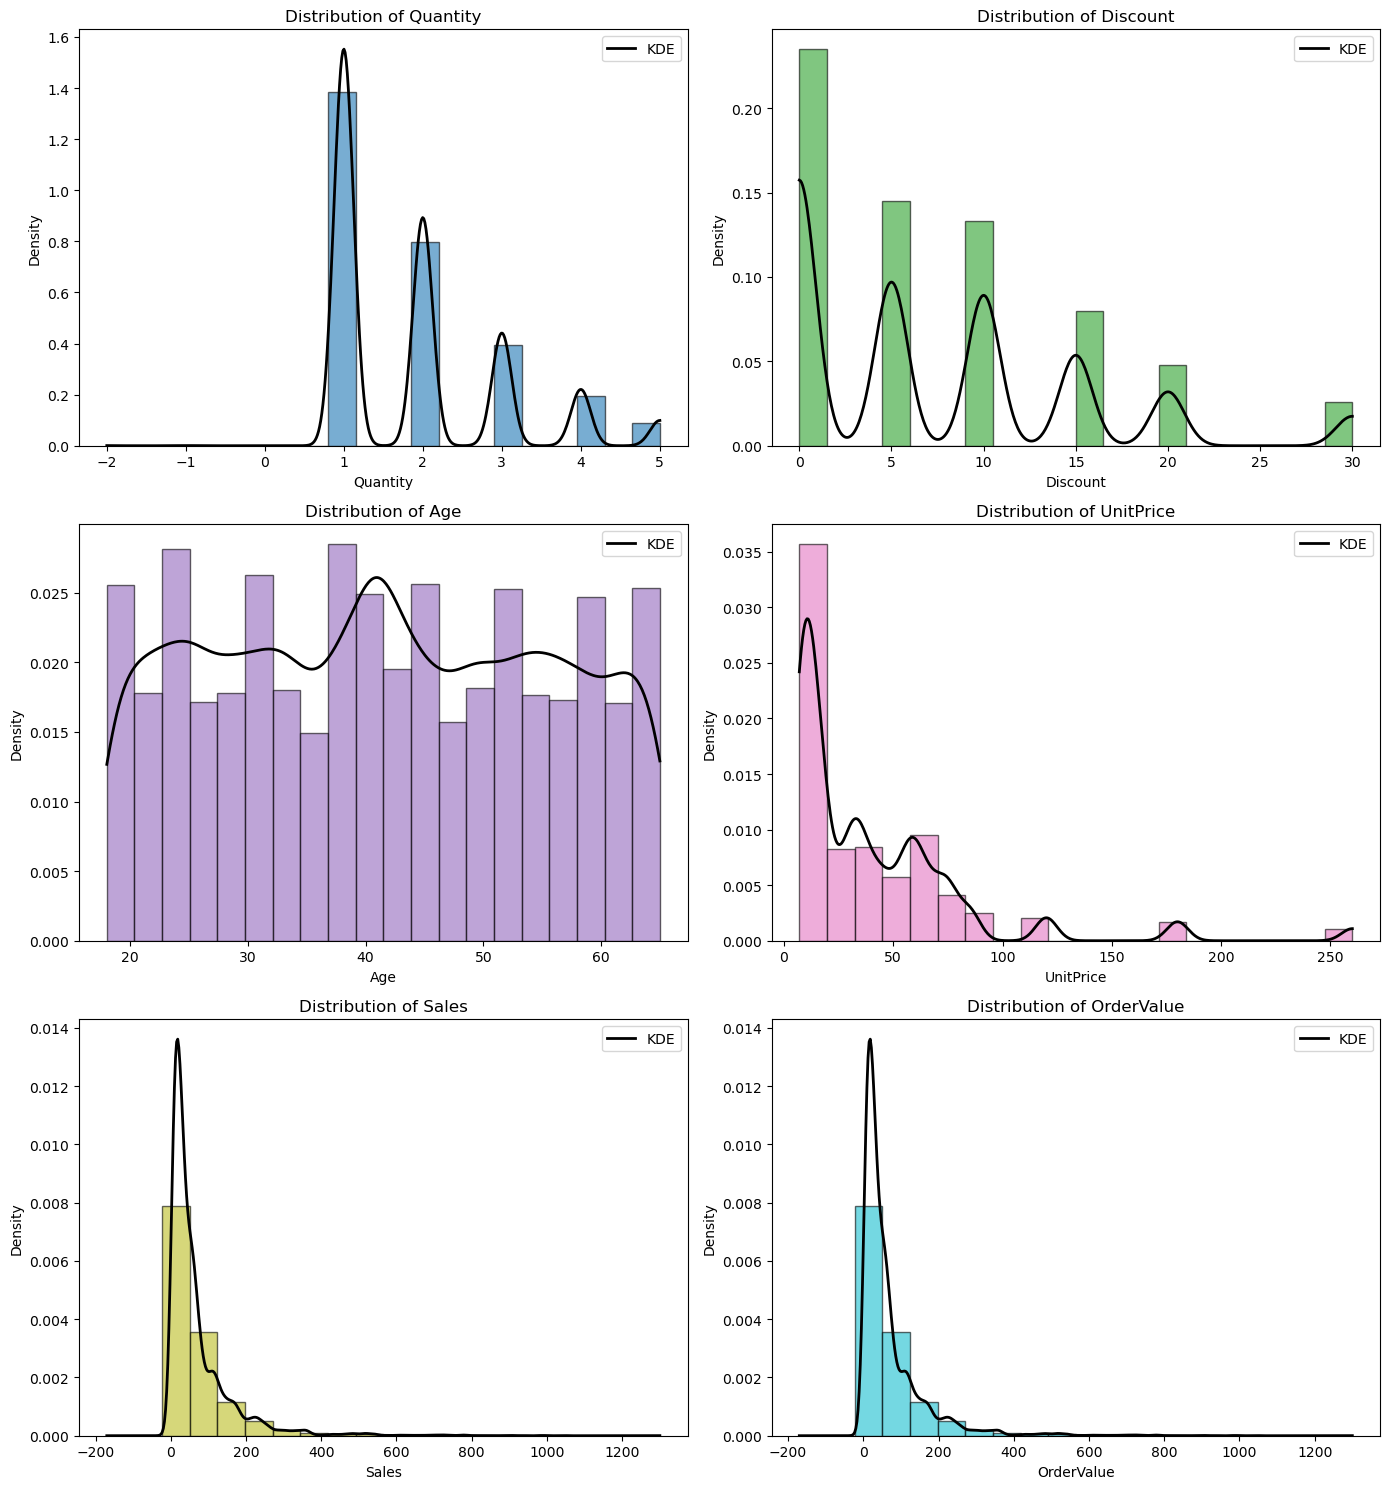

In [19]:
numeric_columns = df.select_dtypes(include = np.number).columns

numeric_columns = [
    column for column in numeric_columns
    if column not in ["OrderID", "CustomerID", "ProductID"]
]

n = len(numeric_columns)

n_cols = 2
n_rows = int(np.ceil(n/n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize = (14,5*n_rows)
)

axes = np.array(axes).flatten()

colors = plt.cm.tab10(np.linspace(0,1,n))

for i, column in enumerate(numeric_columns):
    data = df[column].dropna()
    axes[i].hist(
        data,
        bins = 20,
        density = True,
        alpha = 0.6,
        color = colors[i],
        edgecolor = "black"
    )
    if data.nunique() > 1:
        kde = gaussian_kde(data)
        x = np.linspace(
            data.min(),
            data.max(),
            500
        )
        axes[i].plot(
            x,
            kde(x),
            linewidth = 2,
            color = "black",
            label = "KDE"
        )
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Density")
    axes[i].set_title(f"Distribution of {column}")
    axes[i].legend()

for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

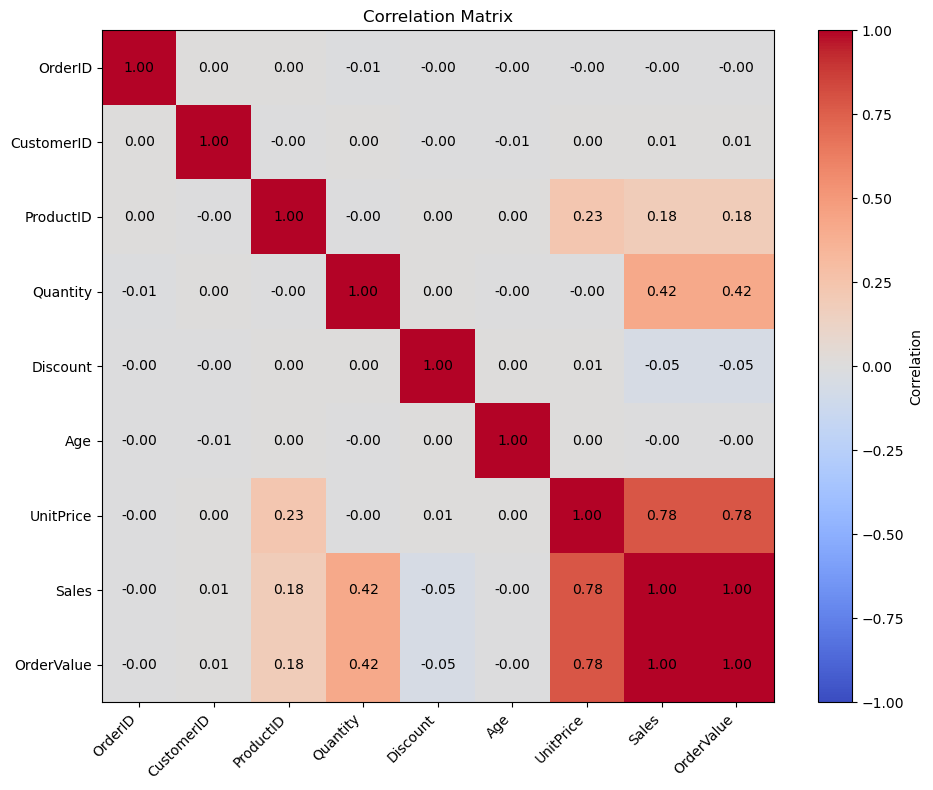

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Exclude ID columns
numeric_columns = [
    column for column in numeric_columns
    if column not in ["orderId", "customerId"]
]

# Create correlation matrix
correlation_matrix = df[numeric_columns].corr()



plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()



PaymentMethod
Gateway       23894
CardToCard    11744
Wallet         8661
Cash           4923
Name: count, dtype: int64


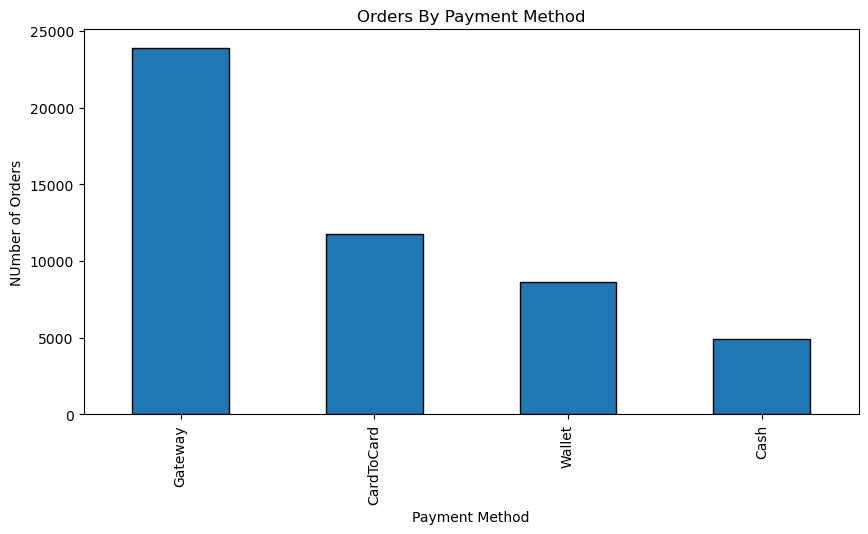

In [31]:
payment_counts = df["PaymentMethod"].value_counts()
print(payment_counts)

plt.figure(figsize=(10,5))
payment_counts.plot(kind = "bar", edgecolor = "black")
plt.title("Orders By Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("NUmber of Orders")
plt.show()

CustomerSegment
Regular    27296
New        17056
VIP         4870
Name: count, dtype: int64


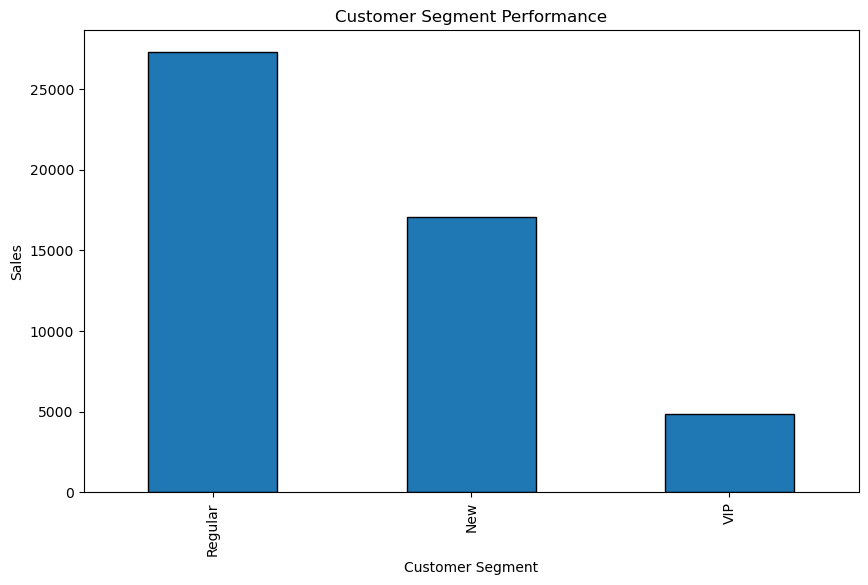

In [43]:
customer_segment_count = df["CustomerSegment"].value_counts()
print(customer_segment_count)

plt.figure(figsize=(10,6))
customer_segment_count.plot(kind = "bar", edgecolor = "black")
plt.title("Customer Segment Performance")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.show()

Status
Completed    45276
Cancelled     2438
Returned      1508
Name: count, dtype: int64


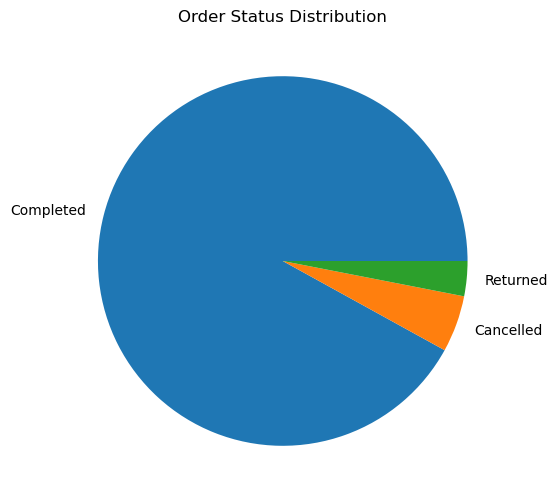

In [51]:
status_counts = df["Status"].value_counts()
print(status_counts)

plt.figure(figsize=(10,6))
plt.pie(status_counts,
       labels=status_counts.index,
       )
plt.title("Order Status Distribution")
plt.show()

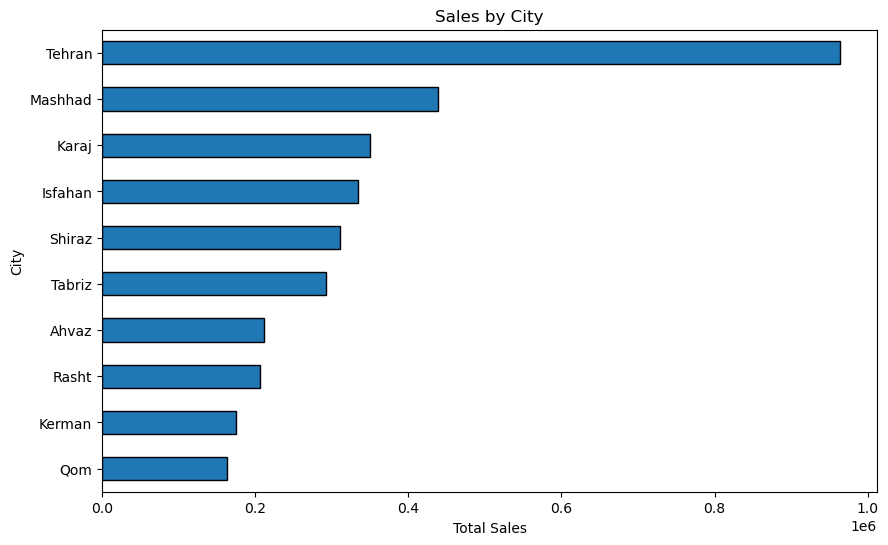

In [57]:
sales_by_city = df.groupby("City")["Sales"].sum().sort_values(ascending=True)

plt.figure(figsize=(10,6))
sales_by_city.plot(kind = "barh",
                  edgecolor = "black")
plt.title("Sales by City")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

Category
Accessories    18189
Electronics    17765
Stationery      5440
Home Office     3122
Wearables       3043
Gaming          1663
Name: count, dtype: int64


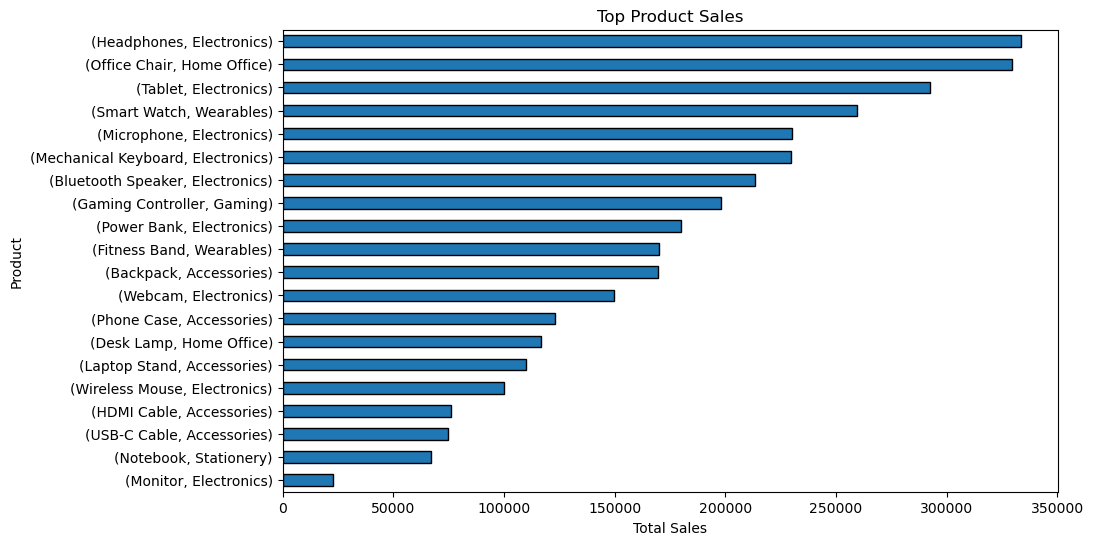

In [73]:
products = df["Category"].value_counts()
print(products.head(10))

products_by_sales = df.groupby(["ProductName","Category"])["Sales"].sum().sort_values(ascending=True)

plt.figure(figsize=(10,6))
products_by_sales.plot(kind = "barh",
                      edgecolor = "black")
plt.title("Top Product Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

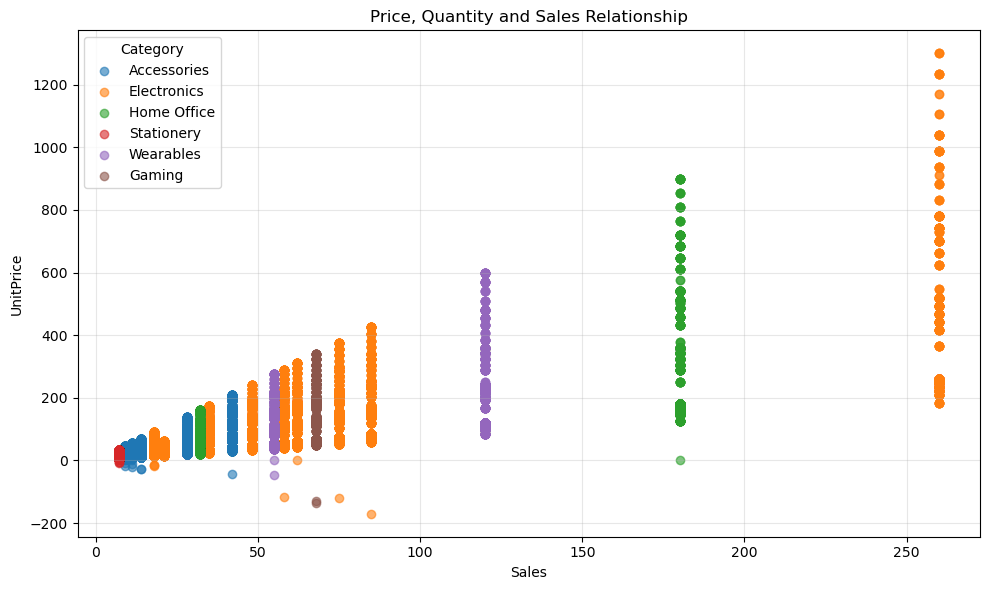

In [9]:
plt.figure(figsize=(10,6))

for Category in df["Category"].unique():
    data = df[df["Category"] == Category]
    plt.scatter(
        data["UnitPrice"],
        data["Sales"],
        alpha = 0.6,
        label = Category
    )

plt.title("Price, Quantity and Sales Relationship")
plt.xlabel("Sales")
plt.ylabel("UnitPrice")
plt.legend(title="Category")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Huawei\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


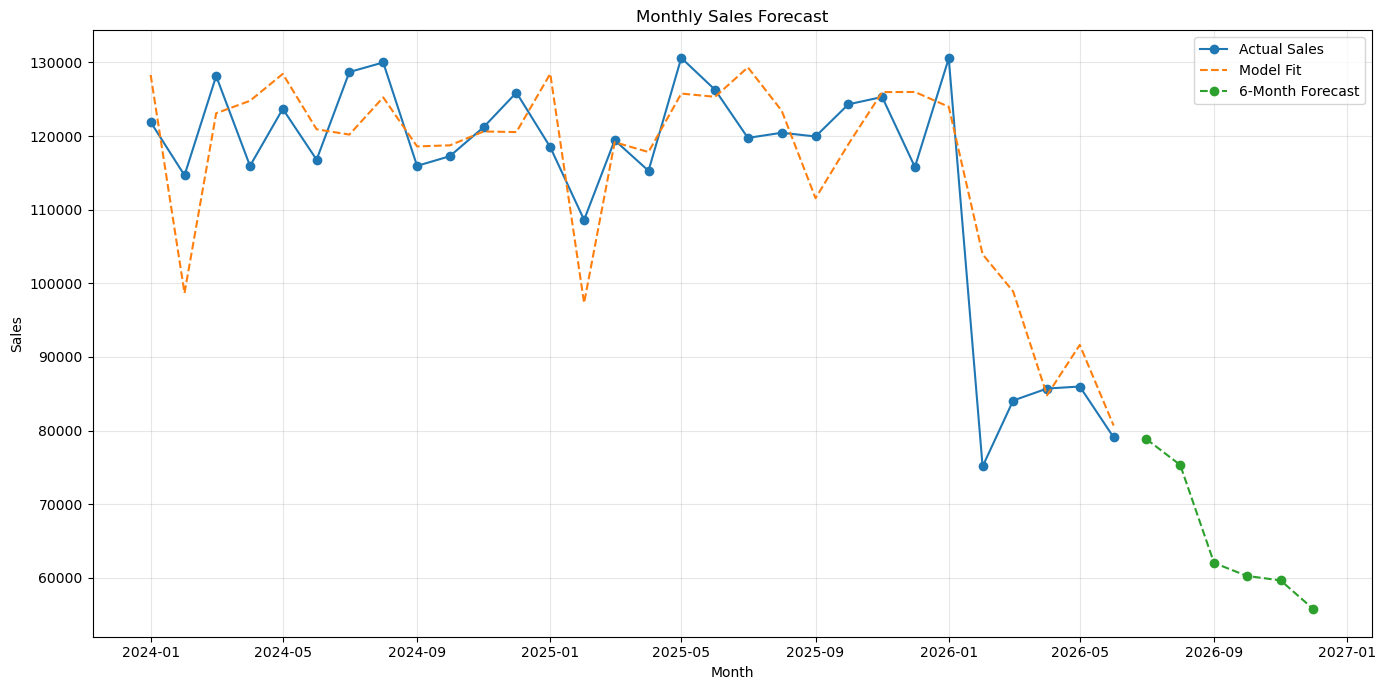

In [27]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df = df.sort_values("OrderDate")

monthly_sales = (
    df.set_index("OrderDate")["Sales"].resample("MS").sum()
)

model = ExponentialSmoothing(
    monthly_sales,
    trend = "add",
    seasonal = "add",
    seasonal_periods = 12
)

model_fit = model.fit()

fitted_values = model_fit.fittedvalues
forecast = model_fit.forecast(6)

forecast_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

# Plot
plt.figure(figsize=(14, 7))

# Actual sales
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    label="Actual Sales"
)

# Model fit
plt.plot(
    fitted_values.index,
    fitted_values.values,
    linestyle="--",
    label="Model Fit"
)

# Forecast
plt.plot(
    forecast_dates,
    forecast.values,
    marker="o",
    linestyle="--",
    label="6-Month Forecast"
)

plt.title("Monthly Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Don't forget the model metrics.

   DayOfWeek  DayNumber  NumberOfOrders  TotalSales
0     Sunday          0            7623    550708.0
1     Monday          1            6645    471094.0
2    Tuesday          2            6639    450081.0
3  Wednesday          3            6583    461102.0
4   Thursday          4            6649    462113.0
5     Friday          5            7503    508819.0
6   Saturday          6            7580    540913.0


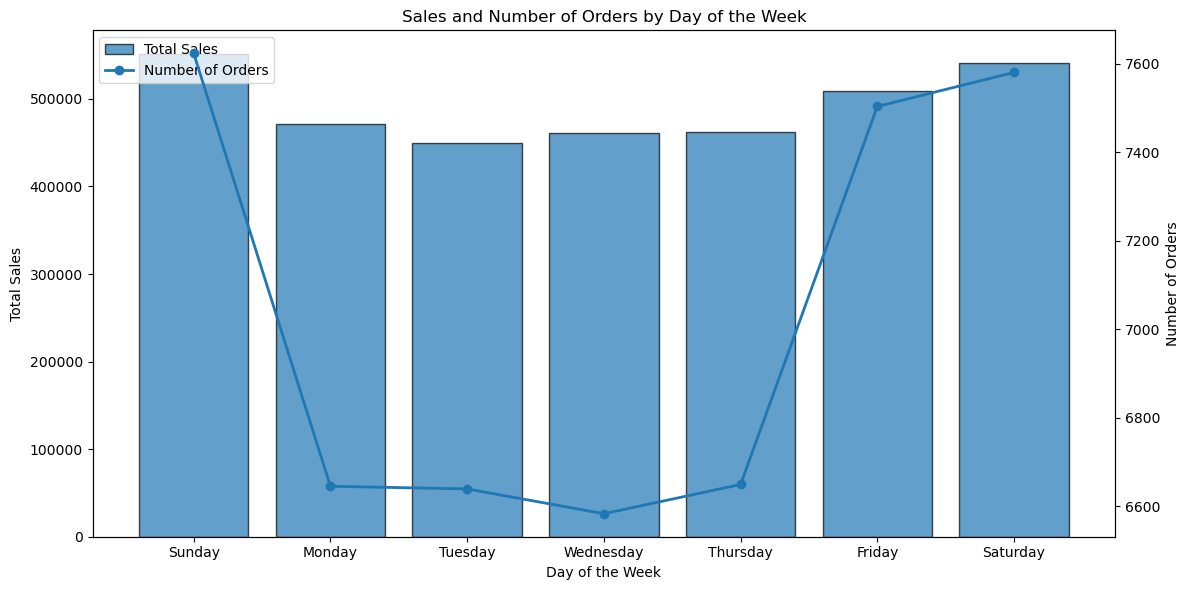

In [22]:
conn = sqlite3.connect(":memory:")

df.to_sql("orders", conn, index=False, if_exists="replace")

query = """
SELECT
     CASE CAST(strftime('%w', OrderDate) AS INTEGER)
         WHEN 0 THEN 'Sunday'
         WHEN 1 THEN 'Monday'
         WHEN 2 THEN 'Tuesday'
         WHEN 3 THEN 'Wednesday'
         WHEN 4 THEN 'Thursday'
         WHEN 5 THEN 'Friday'
         WHEN 6 THEN 'Saturday'
    END AS DayOfWeek,

    CAST(strftime('%w', OrderDate) AS INTEGER) AS DayNumber,

    COUNT(OrderID) AS NumberOfOrders,
    SUM(Sales) AS TotalSales

  FROM orders

  GROUP BY 
      DayOfWeek,
      DayNumber

  ORDER BY
      DayNumber
"""

orders_by_day = pd.read_sql(query, conn)
print(orders_by_day)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sales bars
bars = ax1.bar(
    orders_by_day["DayOfWeek"],
    orders_by_day["TotalSales"],
    edgecolor="black",
    alpha=0.7,
    label="Total Sales"
)

ax1.set_xlabel("Day of the Week")
ax1.set_ylabel("Total Sales")

# Create second y-axis
ax2 = ax1.twinx()

# Orders line
ax2.plot(
    orders_by_day["DayOfWeek"],
    orders_by_day["NumberOfOrders"],
    marker="o",
    linewidth=2,
    label="Number of Orders"
)

ax2.set_ylabel("Number of Orders")

# Title
plt.title("Sales and Number of Orders by Day of the Week")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [30]:
conn = sqlite3.connect(":memory:")

df.to_sql("orders", conn, index=False, if_exists="replace")

query = """

SELECT 
     City,
     Category,
     SUM(Sales) AS TotalSales

   FROM orders
   GROUP BY
       City,
       Category
   ORDER BY
        City,
        Category;
"""

sales_city_category = pd.read_sql(query, conn)
print(sales_city_category)

       City     Category  TotalSales
0     Ahvaz  Accessories     32564.0
1     Ahvaz  Electronics    109886.0
2     Ahvaz       Gaming     12472.0
3     Ahvaz  Home Office     25722.0
4     Ahvaz   Stationery      3878.0
5     Ahvaz    Wearables     26533.0
6   Isfahan  Accessories     57759.0
7   Isfahan  Electronics    162173.0
8   Isfahan       Gaming     18036.0
9   Isfahan  Home Office     44500.0
10  Isfahan   Stationery      7093.0
11  Isfahan    Wearables     44970.0
12    Karaj  Accessories     53846.0
13    Karaj  Electronics    178477.0
14    Karaj       Gaming     22277.0
15    Karaj  Home Office     43638.0
16    Karaj   Stationery      7034.0
17    Karaj    Wearables     44901.0
18   Kerman  Accessories     29613.0
19   Kerman  Electronics     89541.0
20   Kerman       Gaming     10530.0
21   Kerman  Home Office     21405.0
22   Kerman   Stationery      3639.0
23   Kerman    Wearables     20443.0
24  Mashhad  Accessories     69337.0
25  Mashhad  Electronics    222576.0
2

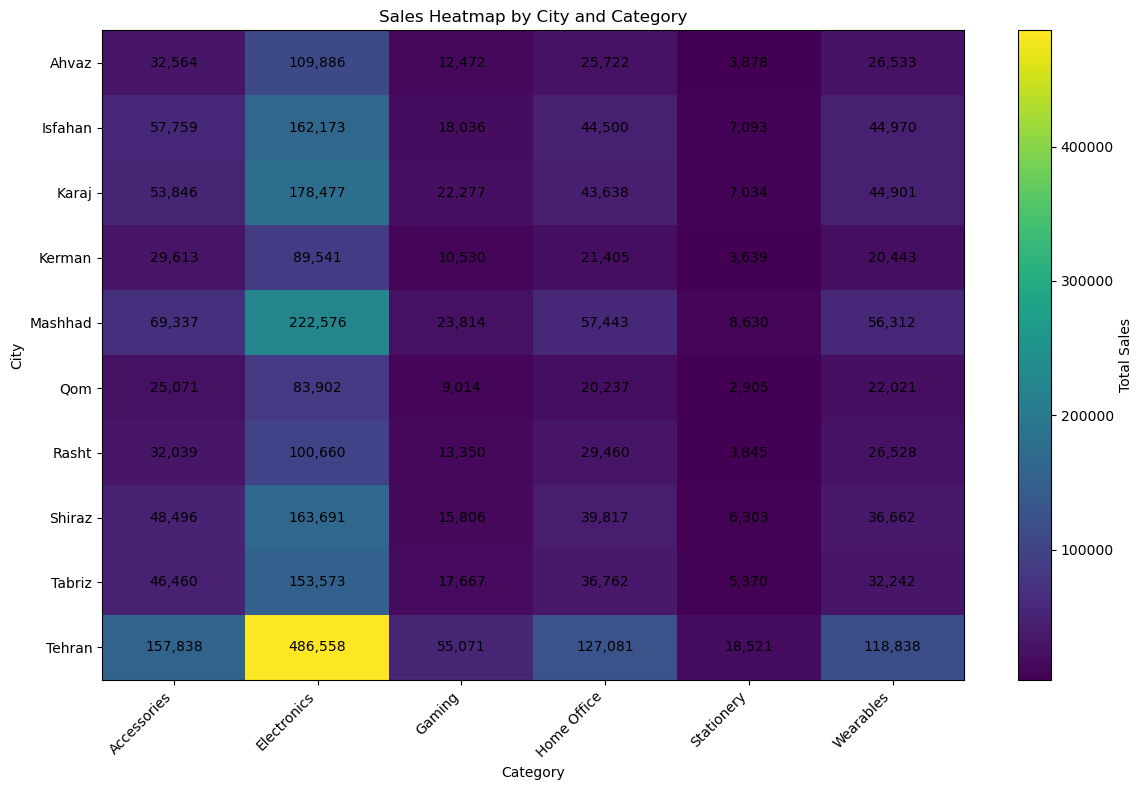

In [34]:
heatmap_data = sales_city_category.pivot(
    index="City",
    columns="Category",
    values="TotalSales"
)

# Plot heatmap
plt.figure(figsize=(12, 8))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Total Sales")

# Axis labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Category")
plt.ylabel("City")
plt.title("Sales Heatmap by City and Category")

# Add values to cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:,.0f}",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

  AgeGroup  TotalSales
0    18-24    493915.0
1    25-34    739817.0
2    35-44    775854.0
3    45-54    685712.0
4    55-64    668276.0
5      65+     81256.0


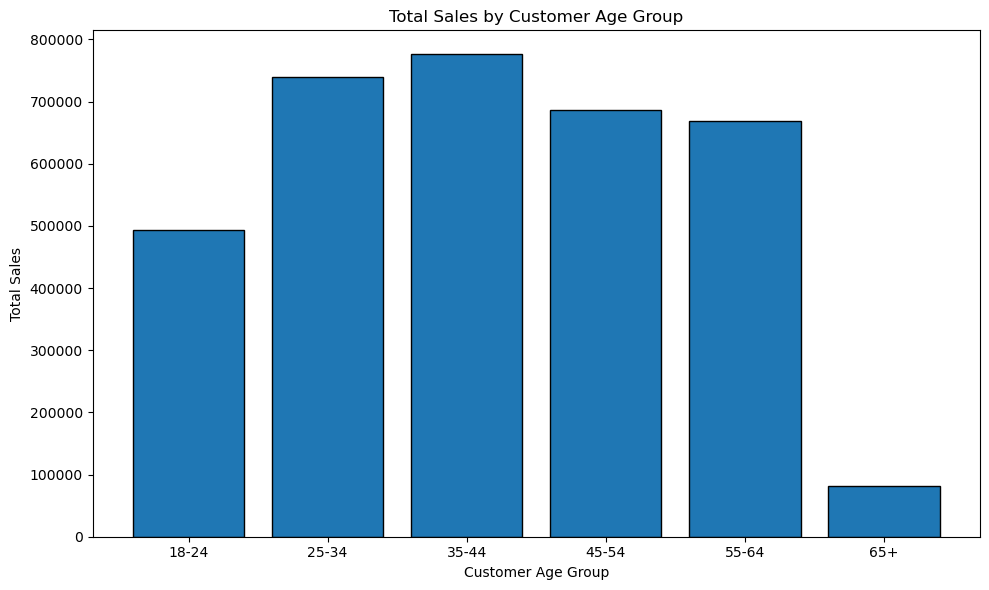

In [40]:
conn = sqlite3.connect(":memory:")

df.to_sql("orders", conn, index=False, if_exists="replace")

query = """
SELECT
     CASE
         WHEN Age < 18 THEN "Under 18"
         WHEN Age BETWEEN 18 AND 24 THEN "18-24"
         WHEN Age BETWEEN 25 AND 34 THEN "25-34"
         WHEN Age BETWEEN 35 AND 44 THEN "35-44"
         WHEN Age BETWEEN 45 AND 54 THEN "45-54"
         WHEN Age BETWEEN 55 AND 64 THEN "55-64"
         WHEN Age >= 65 THEN "65+"
     END AS AgeGroup,

     SUM(Sales) AS TotalSales
  FROM orders
  WHERE Age IS NOT NULL
  GROUP BY AgeGroup
  ORDER BY
       CASE
        WHEN AgeGroup = 'Under 18' THEN 1
        WHEN AgeGroup = '18-24' THEN 2
        WHEN AgeGroup = '25-34' THEN 3
        WHEN AgeGroup = '35-44' THEN 4
        WHEN AgeGroup = '45-54' THEN 5
        WHEN AgeGroup = '55-64' THEN 6
        WHEN AgeGroup = '65+' THEN 7
    END;
"""

sales_by_age = pd.read_sql(query, conn)
print(sales_by_age)

plt.figure(figsize=(10, 6))

plt.bar(
    sales_by_age["AgeGroup"],
    sales_by_age["TotalSales"],
    edgecolor="black"
)

plt.title("Total Sales by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

      Category  TotalOrders  CancelledOrders  ReturnedOrders  \
0  Accessories        18189              913             563   
1  Electronics        17765              889             518   
2       Gaming         1663               81              56   
3  Home Office         3122              144              93   
4   Stationery         5440              270             195   
5    Wearables         3043              141              83   

   CancellationRate  ReturnRate  
0              5.02        3.10  
1              5.00        2.92  
2              4.87        3.37  
3              4.61        2.98  
4              4.96        3.58  
5              4.63        2.73  


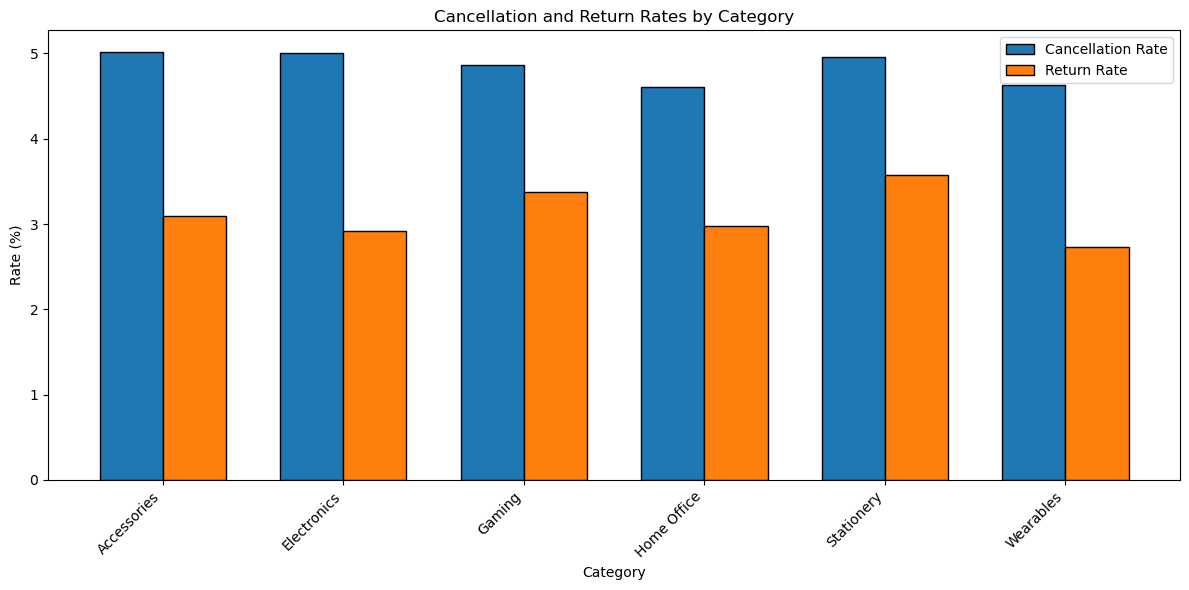

In [54]:
conn = sqlite3.connect(":memory:")

df.to_sql("orders", conn, index=False, if_exists="replace")

query= """
SELECT
     Category,
     COUNT(OrderID) AS TotalOrders,
     SUM(
         CASE
             WHEN LOWER(Status) = "cancelled" THEN 1
             ELSE 0
         END
     ) AS CancelledOrders,

     SUM(
         CASE
             WHEN LOWER(Status) = "returned" THEN 1
             ELSE 0
        END
     ) AS ReturnedOrders,

     ROUND(
           100.0 * SUM(
                       CASE
                           WHEN LOWER(Status) = "cancelled" THEN 1
                           ELSE 0
                        END
           ) / COUNT(OrderID), 2
     ) AS CancellationRate,

     ROUND(
           100.0 * SUM(
                       CASE
                           WHEN LOWER(Status) = "returned" THEN 1
                           ELSE 0
                        END
           ) / COUNT(OrderID), 2
     ) AS ReturnRate

FROM orders
GROUP BY Category
ORDER BY Category

"""

category_rates = pd.read_sql(query, conn)
print(category_rates)

plt.figure(figsize=(12, 6))

x = range(len(category_rates))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    category_rates["CancellationRate"],
    width=width,
    label="Cancellation Rate",
    edgecolor="black"
)

plt.bar(
    [i + width/2 for i in x],
    category_rates["ReturnRate"],
    width=width,
    label="Return Rate",
    edgecolor="black"
)

plt.xticks(
    x,
    category_rates["Category"],
    rotation=45,
    ha="right"
)

plt.xlabel("Category")
plt.ylabel("Rate (%)")
plt.title("Cancellation and Return Rates by Category")

plt.legend()

plt.tight_layout()
plt.show()

In [7]:
df.groupby("Category")["Sales"].sum().sort_values(ascending = False)

Category
Electronics    1751037.0
Accessories     553023.0
Home Office     446065.0
Wearables       429450.0
Gaming          198037.0
Stationery       67218.0
Name: Sales, dtype: float64

In [9]:
average_order_value = df["Sales"].sum() / df["OrderID"].nunique()
print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 69.99
